# rider_kothe

Vortex-in-a-box: the disk stretches into a thin spiral filament by $t=4$, the flow reverses, and it
unwinds back to a disk at $t=8$. This notebook draws two of the case's evidence figures from the
shipped transport-only runs, the validated configuration ($\psi$ transported with `svv_psi`
$c_0=0.1$, $N/2$; no redistancing; $\xi=1$, $\gamma=1$, $N=5$):

- `evidence/rider_snapshots.png`: $\phi$ and $\psi$ at maximum stretch ($t=4$) and at the return
  ($t=8$), against the exact interface (`rider_kothe_xi10`, $H=1/64$);
- `evidence/rider_grad_psi.png`: $|\nabla\psi|$ over the interface band against $t$, at $H=1/64$
  and $1/128$ (`rider_kothe_xi10`, `rider_h128`).

$E_r$ is quoted only at $t=8$, where the exact solution is the initial disk (README, "Results").
The convergence and redistancing figures are made by the gitignored `logs/figs/figs_rk.py`, the
animations by `logs/anim/anim_rk.py` (README, "Evidence").

In [1]:
import glob, os, sys, logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpi4py import MPI
from pysemtools.io.ppymech.neksuite import preadnek
from pysemtools.datatypes.msh import Mesh as msh_c
from pysemtools.datatypes.field import Field as field_c
from pysemtools.datatypes.coef import Coef
sys.path.insert(0, "/lscratch/sieburgh/code/illustrations")
from kthviz import apply_style, PALETTE, KTH, CYCLE, cmap
apply_style(mode="thesis")
logging.disable(logging.INFO)
comm = MPI.COMM_WORLD
os.makedirs("evidence", exist_ok=True)

def frames(tag):
    return sorted(glob.glob(f"output_{tag}/field0.f?????"))

def load(f):
    o = field_c(comm, data=preadnek(f, comm))
    return o.t, o.fields["temp"][0], o.fields["scal"][0]      # t, phi, psi

def exact_interface(t, dt=1e-3, hmax=2e-4):
    """Markers on the initial circle, RK4 in time, refined where a gap exceeds hmax.
    The flow is time-reversible, so x(t) = x(8 - t) after the reversal."""
    t = 8.0 - t if t > 4.0 else t
    th = np.linspace(0, 2*np.pi, 4000, endpoint=False)
    p = np.c_[0.5 + 0.15*np.cos(th), 0.75 + 0.15*np.sin(th)]
    vel = lambda p, s: np.cos(np.pi*s/8)*np.c_[np.sin(np.pi*p[:, 0])**2*np.sin(2*np.pi*p[:, 1]),
                                              -np.sin(2*np.pi*p[:, 0])*np.sin(np.pi*p[:, 1])**2]
    tc = 0.0
    while tc < t - 1e-12:
        h = min(dt, t - tc)
        k1 = vel(p, tc); k2 = vel(p + h/2*k1, tc + h/2)
        k3 = vel(p + h/2*k2, tc + h/2); k4 = vel(p + h*k3, tc + h)
        p = p + h/6*(k1 + 2*k2 + 2*k3 + k4); tc += h
        gap = np.linalg.norm(np.roll(p, -1, 0) - p, axis=1) > hmax
        if gap.any():
            pm, p1, p2 = np.roll(p, 1, 0), np.roll(p, -1, 0), np.roll(p, -2, 0)
            mid = (-pm + 9*p + 9*p1 - p2)/16
            w = np.nonzero(gap)[0]
            p = np.insert(p, w + 1, mid[w], axis=0)
    return np.vstack([p, p[:1]])

## Two snapshots: maximum stretch and the return

$\phi$ uses the diverging phase map ($\phi=1$ blue), with values below 0 in KTH yellow and above 1 in
KTH green, so a boundedness violation shows. $\psi$ is clipped to $\pm0.05$, and its zero contour is
drawn solid. The dashed line is the exact interface.

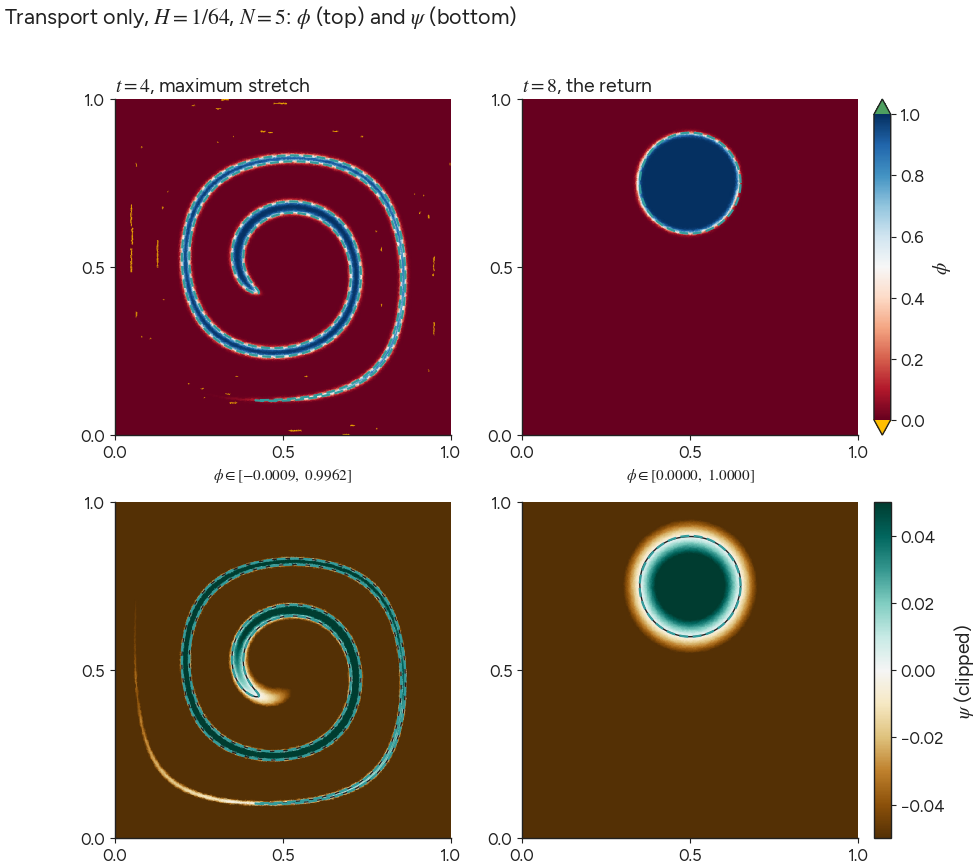

In [2]:
TAG = "rider_kothe_xi10"
f = frames(TAG)
msh = msh_c(comm, data=preadnek(f[0], comm))
iz = msh.z.shape[1]//2
tri = mtri.Triangulation(msh.x[:, iz].ravel(), msh.y[:, iz].ravel())
ts = np.array([field_c(comm, data=preadnek(ff, comm)).t for ff in f])

CM = cmap("phase").copy(); CM.set_under(KTH["yellow"]); CM.set_over(KTH["green"])
PSI_LIM = 0.05
fig, axes = plt.subplots(2, 2, figsize=(10.2, 9.6))
for col, (tw, title) in enumerate([(4.0, "$t=4$, maximum stretch"), (8.0, "$t=8$, the return")]):
    t, phi, psi = load(f[int(np.argmin(abs(ts - tw)))])
    ex = exact_interface(t)
    p, q = phi[:, iz].ravel(), psi[:, iz].ravel()
    m0 = axes[0, col].tripcolor(tri, p, shading="gouraud", cmap=CM, vmin=0.0, vmax=1.0)
    m1 = axes[1, col].tripcolor(tri, np.clip(q, -PSI_LIM, PSI_LIM), shading="gouraud",
                               cmap=cmap("signed"), vmin=-PSI_LIM, vmax=PSI_LIM)
    axes[1, col].tricontour(tri, q, levels=[0.0], colors=PALETTE["text"], linewidths=1.0)
    for row in range(2):
        a = axes[row, col]
        a.plot(ex[:, 0], ex[:, 1], color=PALETTE["interface"], lw=1.6, ls=(0, (4, 2)))
        a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
        a.set_xticks([0, 0.5, 1]); a.set_yticks([0, 0.5, 1])
    axes[0, col].set_title(title, loc="left")
    axes[0, col].set_xlabel("$\\phi\\in[%.4f,\\ %.4f]$" % (p.min(), p.max()), fontsize=11)
fig.colorbar(m0, ax=axes[0], fraction=0.035, pad=0.02, label="$\\phi$", extend="both")
fig.colorbar(m1, ax=axes[1], fraction=0.035, pad=0.02, label="$\\psi$ (clipped)")
fig.suptitle("Transport only, $H=1/64$, $N=5$: $\\phi$ (top) and $\\psi$ (bottom)", x=0.02, ha="left")
fig.savefig("evidence/rider_snapshots.png", dpi=150)

## One plot: $|\nabla\psi|$ follows the strain out and back

$D|\nabla\psi|/Dt = -|\nabla\psi|\,(\mathbf n\cdot\nabla\mathbf u\cdot\mathbf n)$, and this flow's
strain reverses with it, so the drift integrates back to zero. The band is $\phi(1-\phi)>10^{-4}$,
the compression band; the line is its mean and the shading its 5–95% range. The gradient here is
element-local, so it differs slightly from the run log's gathered band report.

run                     t=0      t=4      t=8   band mean |grad psi|


rider_kothe_xi10      1.000    7.706    1.008


rider_h128            1.000    7.991    1.000


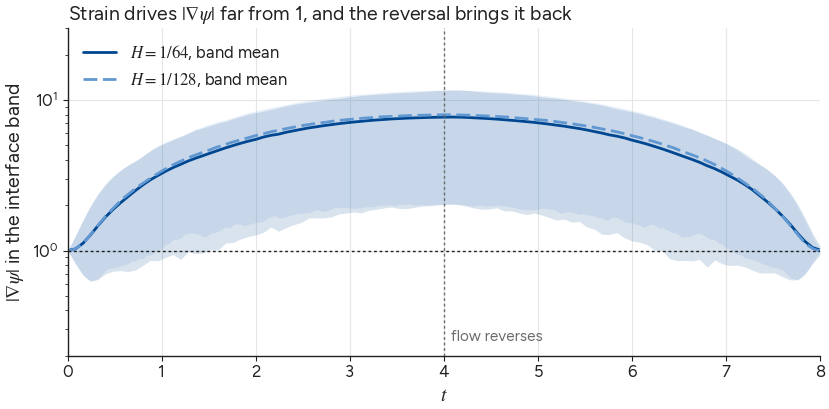

In [3]:
RUNS = [("rider_kothe_xi10", "$H=1/64$", CYCLE[0], "-"), ("rider_h128", "$H=1/128$", CYCLE[4], (0, (5, 2)))]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
print(f"{'run':<18} {'t=0':>8} {'t=4':>8} {'t=8':>8}   band mean |grad psi|")
for tag, label, col, ls in RUNS:
    f = frames(tag)
    m = msh_c(comm, data=preadnek(f[0], comm)); c = Coef(m, comm)
    t_, mean, lo, hi = [], [], [], []
    for ff in f:
        t, phi, psi = load(ff)
        g = np.sqrt(c.dudxyz(psi, c.drdx, c.dsdx, c.dtdx)**2 + c.dudxyz(psi, c.drdy, c.dsdy, c.dtdy)**2)
        b = phi*(1.0 - phi) > 1e-4
        t_.append(t); mean.append(g[b].mean()); lo.append(np.percentile(g[b], 5)); hi.append(np.percentile(g[b], 95))
    t_, mean = np.array(t_), np.array(mean)
    ax.fill_between(t_, lo, hi, color=col, alpha=0.15, lw=0)
    ax.plot(t_, mean, color=col, lw=2, ls=ls, label=label + ", band mean")
    at = lambda s: mean[int(np.argmin(abs(t_ - s)))]
    print(f"{tag:<18} {at(0):8.3f} {at(4):8.3f} {at(8):8.3f}")
ax.axhline(1.0, color=PALETTE["text"], lw=1, ls=(0, (2, 2)))
ax.axvline(4.0, color="#6B6B6B", lw=1, ls=(0, (2, 2)))
ax.text(4.08, 0.25, "flow reverses", color="#6B6B6B", fontsize=11)
ax.set_yscale("log"); ax.set_xlim(0, 8); ax.set_ylim(0.2, 30)
ax.set_xlabel("$t$"); ax.set_ylabel("$|\\nabla\\psi|$ in the interface band")
ax.set_title("Strain drives $|\\nabla\\psi|$ far from 1, and the reversal brings it back", loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(True, color=PALETTE["guide"], lw=0.8); ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("evidence/rider_grad_psi.png", dpi=150)